# `mammos_mumag` quickstart

`mammos_mumag` can compute hysteresis loops of magnetic materials using finite elements.

Requirements:
- `mammos` and `esys-escript`

In [1]:
import mammos_entity as me
import mammos_units as u
import pandas as pd
from mammos_mumag import hysteresis, mesh

In [2]:
u.set_enabled_equivalencies(u.magnetic_flux_field())

## Hysteresis simulation

The `hysteresis.run` function computes a hysteresis loop for a homogeneous material with given parameters. We need to pass in a suitable mesh, `mammos_mumag.mesh` provides a sample mesh.

In [3]:
hysteresis_result = hysteresis.run(
    mesh="cube20_singlegrain_msize1",
    Ms=me.Ms(1280000, unit="A/m"),
    A=me.A(7.7e-12, unit="J/m"),
    K1=me.Ku(4300000, unit="J/m3"),
    hstart=(10 * u.T).to("A/m"),
    hfinal=(-10 * u.T).to("A/m"),
    hnsteps=20,
)

In this case, we are using a single grain cube of side length 20 and mesh size 1. For more information about meshes, look at the [meshes notebook](meshes.ipynb).

## Hysteresis result object

The returned `results_hysteresis` object provides a `plot` method to visualize the computed data. `mammos_mumag.hysteresis` only computes half a hysteresis loop, going from `hstart` to `hfinal`. To show a full loop this function mirrors the computed data and plots it twice:

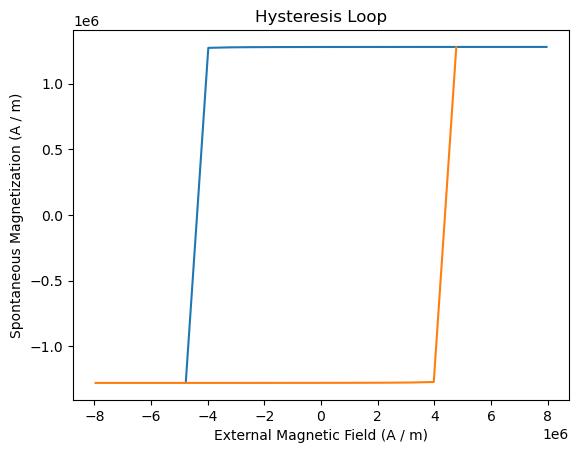

In [4]:
hysteresis_result.plot();

To only see the actual simulation, we can use the flag `duplicate=False`:

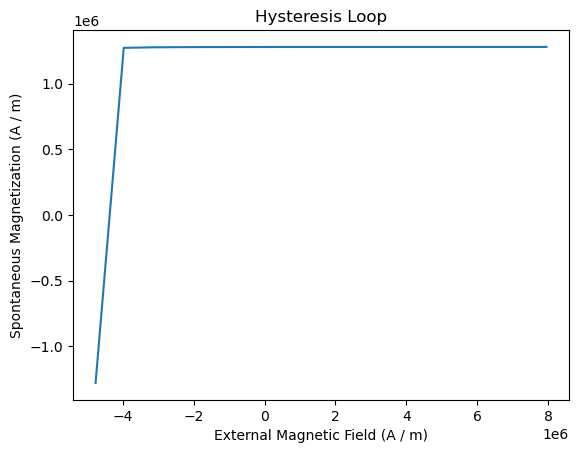

In [5]:
hysteresis_result.plot(duplicate=False);

The results object provides access to `H`, `M` and the energy density:

In [6]:
hysteresis_result.H

Entity(ontology_label='ExternalMagneticField', value=array([ 7957747.15026276,  7161972.43523649,  6366197.72021021,
        5570423.00518393,  4774648.29015766,  3978873.57513138,
        3183098.86010511,  2387324.14507883,  1591549.43005255,
         795774.71502628,        0.        ,  -795774.71502628,
       -1591549.43005255, -2387324.14507883, -3183098.86010511,
       -3978873.57513138, -4774648.29015766]), unit='A / m')

In [7]:
hysteresis_result.M

Entity(ontology_label='SpontaneousMagnetization', value=array([ 1279881.69288156,  1279866.89227949,  1279849.11950386,
        1279827.51932709,  1279800.90422201,  1279767.58596402,
        1279725.09820878,  1279669.7209707 ,  1279595.62585461,
        1279493.25197902,  1279345.99732159,  1279122.86770715,
        1278760.15659451,  1278108.03941543,  1276732.60416053,
        1272769.84628216, -1279800.90723888]), unit='A / m')

In [8]:
hysteresis_result.energy_density

Entity(ontology_label='EnergyDensity', value=array([-16768469.56758716, -15488595.05549823, -14208736.76953903,
       -12928898.08692807, -11649083.39534054, -10369298.50268764,
        -9089551.26462095,  -7809852.57837771,  -6530218.02053254,
        -5250670.67709625,  -3971246.32604583,  -2692003.64323073,
        -1413046.28943735,   -134577.28248443,   1142938.99080965,
         2418102.52586009, -11649083.39531036]), unit='J / m3')

The attribute `configuration_type` contains a list of indices that refer to saved magnetization field configurations. We will use this information later.

In [9]:
hysteresis_result.configuration_type

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2])

We can also get the hysteresis data as a pandas dataframe in SI units:

In [10]:
hysteresis_result.dataframe

,configuration_type,H,M,energy_density
0,1,7.957747e+06,1.279882e+06,-1.676847e+07
1,1,7.161972e+06,1.279867e+06,-1.548860e+07
2,1,6.366198e+06,1.279849e+06,-1.420874e+07
3,1,5.570423e+06,1.279828e+06,-1.292890e+07
4,1,4.774648e+06,1.279801e+06,-1.164908e+07
5,1,3.978874e+06,1.279768e+06,-1.036930e+07
6,1,3.183099e+06,1.279725e+06,-9.089551e+06
7,1,2.387324e+06,1.279670e+06,-7.809853e+06
8,1,1.591549e+06,1.279596e+06,-6.530218e+06
9,1,7.957747e+05,1.279493e+06,-5.250671e+06


We can generate a table in alternate units:

In [11]:
df = pd.DataFrame(
    {
        "mu0_H": hysteresis_result.H.q.to(u.T),
        "J": hysteresis_result.M.q.to(u.T),
    },
)
df.head()

,mu0_H,J
0,10.0,1.608347
1,9.0,1.608328
2,8.0,1.608306
3,7.0,1.608279
4,6.0,1.608245


## Visualizing magnetization configurations

To plot the hysteresis loop (including the available configurations), run

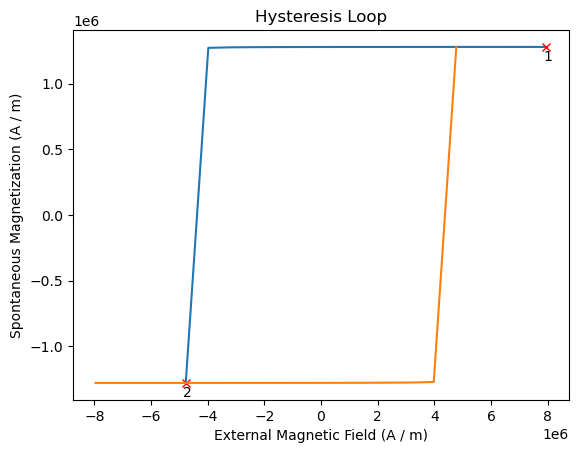

In [12]:
hysteresis_result.plot(configuration_marks=True);

We can get the location of the saved configurations from the attribute `configurations`:

In [13]:
hysteresis_result.configurations

{1: PosixPath('/home/pepe/repo/mammos/mammos-mumag/examples/hystloop/hystloop_0001.vtu'),
 2: PosixPath('/home/pepe/repo/mammos/mammos-mumag/examples/hystloop/hystloop_0002.vtu')}

To inspect the configurations more conveniently directly in the notebook we can use the `plot_configuration` function of `hysteresis_result`. We need to pass the index and get an interactive 3D plot (using pyvista):

In [14]:
hysteresis_result.plot_configuration(1)

Widget(value='<iframe src="http://localhost:39889/index.html?ui=P_0x707158df8a50_0&reconnect=auto" class="pyvi…

Note: the small object size is a consequence of the empty sphere around the cube.

## Passing a different mesh

In this notebook we have used a mesh with side length 20. `mammos_mumag` comes with some pre-computed meshes, stored on Zenodo or available locally.
For example, we could use instead

In [15]:
mesh.Mesh("cube50_singlegrain_msize1")

Mesh('cube50_singlegrain_msize1')

Or a local mesh (assuming it satisfies the assumptions on the mesh, more about that in the [meshes notebook](meshes.ipynb#Meshes)).

In [16]:
mesh.Mesh("hystloop/hystloop.fly")

Mesh('hystloop/hystloop.fly')